In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle

from chronos import Chronos2Pipeline


# Forcing Fitting Extension

In [2]:
with open("/glade/work/stevenxu/FAIR_models/origional_model_extension.pkl", "rb") as f_in:
    f1 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top10_model_extension.pkl", "rb") as f_in:
 #   f2 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top20_model_extension.pkl", "rb") as f_in:
 #   f3 = pickle.load(f_in)

## Chronos Fitting

In [3]:
from chronos import Chronos2Pipeline
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")


In [4]:
no_emission_species = []
for specie in f1.species:
    da = f1.emissions.sel(scenario = f1.scenarios[3], specie=specie).mean(dim="config")
    if da.sum() == 0:
        no_emission_species.append(specie)

no_emission_species

['Solar',
 'Volcanic',
 'Aerosol-radiation interactions',
 'Aerosol-cloud interactions',
 'Ozone',
 'Light absorbing particles on snow and ice',
 'Stratospheric water vapour',
 'Land use',
 'Equivalent effective stratospheric chlorine']

In [21]:
# Start from your xarray
full_da = f1.emissions.sel(
    scenario=f1.scenarios[3]
).mean(dim='config')

# To DataFrame: columns -> timepoints, scenario, specie, value
full_df = full_da.to_dataframe('value').reset_index()

# Remove species with no emissions
full_df = full_df[~full_df['specie'].isin(no_emission_species)].copy()

# Convert FAIR timepoints (1750.5, 1751.5, …) to integer years
full_df['year'] = full_df['timepoints'].astype(int)

# 1) extend data to 2300 (no datetime here, just numeric years)
full_df = full_df[full_df['year'] <= 2300].copy()

# 2) train data up to and including 2023
train_df = full_df[full_df['year'] <= 2023].copy()

# 3) future horizon: 2024–2300
future_df = full_df[full_df['year'] > 2023].copy().drop(columns='value')

# (optional) ground-truth for plotting/eval – same years as future_df
test_df = full_df[full_df['year'] > 2023].copy()

prediction_length = future_df['year'].nunique()




In [52]:
# 4) Call Chronos using 'year' as the timestamp column
pred_df = pipeline.predict_df(
    train_df,
    future_df=future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column='specie',
    timestamp_column='year',  # <--- numeric timestamps
    target='value',
)
pred_df["year"] = pred_df["year"].astype("int64") - 0.5

pred_df

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


,specie,year,target_name,predictions,0.1,0.5,0.9
0,CO2 FFI,2023.5,value,37.661839,35.623844,37.661839,39.319561
1,CO2 FFI,2024.5,value,37.860596,35.252483,37.860596,39.962120
2,CO2 FFI,2025.5,value,38.111355,34.612320,38.111355,40.802177
3,CO2 FFI,2026.5,value,38.386593,34.597855,38.386593,41.746807
4,CO2 FFI,2027.5,value,38.622993,33.835007,38.622993,42.921150
...,...,...,...,...,...,...,...
14347,HFC-4310mee,2294.5,value,0.053166,-0.004072,0.053166,3.965860
14348,HFC-4310mee,2295.5,value,0.048463,0.001347,0.048463,2.682764
14349,HFC-4310mee,2296.5,value,0.047401,0.001700,0.047401,2.949629
14350,HFC-4310mee,2297.5,value,0.056684,-0.000244,0.056684,2.881621


In [22]:
history_df = train_df.copy()
history_df["year"] = history_df["year"] + 0.5
history_df

,timepoints,specie,scenario,value,year
0,1750.5,CO2 FFI,medium-extension,0.009306,1750.5
1,1750.5,CO2 AFOLU,medium-extension,0.010992,1750.5
2,1750.5,CO2,medium-extension,0.020298,1750.5
3,1750.5,CH4,medium-extension,38.246272,1750.5
4,1750.5,N2O,medium-extension,1.000464,1750.5
...,...,...,...,...,...
16700,2023.5,HFC-236fa,medium-extension,0.448029,2023.5
16701,2023.5,HFC-245fa,medium-extension,18.008540,2023.5
16702,2023.5,HFC-32,medium-extension,8.216448,2023.5
16703,2023.5,HFC-365mfc,medium-extension,4.413322,2023.5


In [ ]:
def plot_fair_chronos_combined(specie, showPlot=True, savePlot=False, save_path='/glade/u/home/stevenxu/FAIRproject/graph_outputs/Chronos_plots'):

    scenario_names = list(f1.scenarios)     # all FAIR scenarios

    # -------------------------
    # 1. Chronos predictions
    # -------------------------
    spec_pred = (
        pred_df[pred_df["specie"] == specie]
        .sort_values("year")
    )

    x_pred   = spec_pred["year"]
    y_pred   = spec_pred["predictions"]
    low_pred = spec_pred["0.1"]
    high_pred= spec_pred["0.9"]

    # --------------------------
    #   HISTORY PART (FAIR)
    # --------------------------
    spec_hist = history_df[history_df["specie"] == specie].copy()
    spec_hist = spec_hist.sort_values("year")

    x_hist = spec_hist["year"]       # e.g., 1750.5, 1751.5 ...
    y_hist = spec_hist["value"]

    # -------------------------
    # 2. FAIR curves (ALL scenarios)
    # -------------------------
    fair_lines = {}

    for scen in scenario_names:
        da = (
            f1.emissions
            .sel(scenario=scen, specie=specie, timepoints =slice(2023.5, 2300.5))
            .mean(dim="config")              # mean over config
        )
        df = da.to_dataframe("fair_value").reset_index()
        df["year"] = df["timepoints"]         # FAIR uses mid-year floats

        fair_lines[scen] = df.sort_values("year")

    # -------------------------
    # 3. PLOT everything
    # -------------------------
    plt.figure(figsize=(8, 5))


    # History curve
    plt.plot(x_hist, y_hist, label="history", color="Black", linewidth=2)

    # Plot ALL FAIR scenarios
    for scen, df in fair_lines.items():
        plt.plot(
            df["year"],
            df["fair_value"],
            linewidth=1.0,
            label=f"FAIR {scen}"
        )

    # Chronos forecast
    plt.plot(
        x_pred,
        y_pred,
        color="xkcd:azure",
        linewidth=2.5,
        label="Chronos forecast"
    )

    # Prediction interval (darker as requested)
    plt.fill_between(
        x_pred,
        low_pred,
        high_pred,
        alpha=0.2,
        color="xkcd:azure",
        label="0.1–0.9 interval"
    )

    plt.axvline(x=2023, color="black", linestyle="--", linewidth=1.2, alpha=0.5)

    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.title(f"Chronos Forecast: {specie}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if showPlot:
        plt.show()

    if savePlot:
        save_dir = save_path + f'/{specie}_Chronos_Forecast.png'
        plt.savefig(save_dir)

    plt.close()


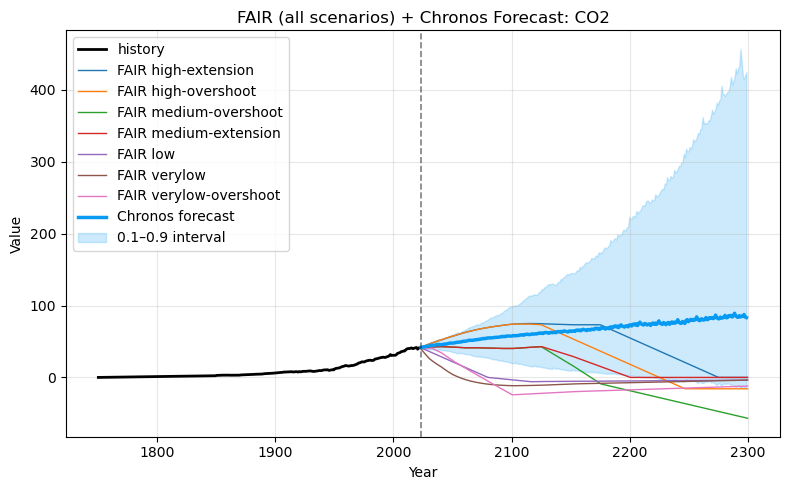

In [62]:
plot_fair_chronos_combined('CO2', showPlot=True, savePlot=False, save_path='/glade/u/home/stevenxu/FAIRproject/graph_outputs/Chronos_plots')

In [61]:
for specie in pred_df['specie'].unique():
    plot_fair_chronos_combined(specie, showPlot=False, savePlot=True, save_path='/glade/u/home/stevenxu/FAIRproject/graph_outputs/Chronos_plots')